In [1]:
import sys
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean as cmo
plt.style.use('src/ryan_mplstyle.mplstyle')

from scipy.signal import convolve2d
from scipy.signal.windows import hamming

SRC_DIR = (Path.cwd() /'src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from draw_gaussian_field_from_spectrum import draw_gaussian_field_from_spectrum

In [2]:
# Define a region of 500 km (large enough for spectral analysis)
# With 250 m posting
Lx, Ly = 50, 500 #km
dx, dy = 0.25, 0.25 #km
# Grid for 2km posting (for downsampling after filtering)
dy_2km = 2  # km

Nx, Ny = int(Lx/dx), int(Ly/dy)
Lx, Ly = dx*Nx, dy*Ny

k = np.fft.fftfreq(Nx, d=dx); l = np.fft.fftfreq(Ny, d=dy)
k_mat, l_mat = np.meshgrid(k,l)
Ka_mat = np.sqrt(k_mat**2+l_mat**2)
x = np.arange(-Lx/2,Lx/2,Lx/Nx); y = np.arange(-Ly/2,Ly/2,Ly/Ny)
x_mat, y_mat = np.meshgrid(x,y)

l_2km = np.fft.fftfreq(int(Ly/dy_2km), d=dy_2km)
downsample_stride = int(round(dy_2km / dy))

repeat_num = 200 # total ensumble number
repeat_batch_size = 50 # processed in smaller batch size to fit in memory
batch_sizes = [repeat_batch_size] * (repeat_num // repeat_batch_size)
if repeat_num % repeat_batch_size:
    batch_sizes.append(repeat_num % repeat_batch_size)

In [3]:
# Keep noise fixed at the SWH = 3 m case
noise_mag_ref = (1.32/0.96)**2

noisefloor_2km = 2*(15/0.5)/(2.3**2)
noise_spec_val = noisefloor_2km/(50/0.25)
Noise_spec = np.ones(Ka_mat.shape) * noise_spec_val * noise_mag_ref

In [4]:
# GM spectra with different magnitudes
mag_values = np.array([1, 3, 10, 30])
# Base GM spectra
GM_spec_base = (Ka_mat**2/(Ka_mat**2+5e-5)**2/Ka_mat) * 3e-5; GM_spec_base[0,0]=0

/tmp/ipykernel_30041/207109884.py:4: RuntimeWarning: invalid value encountered in divide
  GM_spec_base = (Ka_mat**2/(Ka_mat**2+5e-5)**2/Ka_mat) * 3e-5; GM_spec_base[0,0]=0


In [5]:
# Create the 2D 17 point Hamming window filter used in SWOT processing to create the 2km data
window_size = 17

# Create 2D filter using outer product and normalize it for convolution
hamm_1d = hamming(window_size)
hamm_filt2d = np.outer(hamm_1d, hamm_1d)
hamm_filt2d = hamm_filt2d / hamm_filt2d.sum()

In [6]:
# Running sums for ensumble averages.
unfiltered_spectra_sum = {
    mag: {
        'total': np.zeros_like(l, dtype=float),
        'GM': np.zeros_like(l, dtype=float),
        'noise': np.zeros_like(l, dtype=float),
    }
    for mag in mag_values
}

filtered_spectra_sum = {
    mag: {
        'total': np.zeros_like(l, dtype=float),
        'GM': np.zeros_like(l, dtype=float),
        'noise': np.zeros_like(l, dtype=float),
    }
    for mag in mag_values
}

filtered_spectra2km_sum = {
    mag: {
        'total': np.zeros_like(l_2km, dtype=float),
        'GM': np.zeros_like(l_2km, dtype=float),
        'noise': np.zeros_like(l_2km, dtype=float),
    }
    for mag in mag_values
}

In [7]:
start_idx = 0

for current_batch_size in batch_sizes:

    # Do the noise-only case first since it does not change with GM magnitude
    SSH_noise_hat, SSH_noise = draw_gaussian_field_from_spectrum(Noise_spec, current_batch_size)
    unfiltered_spectra_sum[mag_values[-1]]['noise'] += current_batch_size * np.mean(
        np.abs(np.fft.fft(SSH_noise, norm='forward', axis=1))**2, axis=(0, 2)
    )
    SSH_noise_filt = np.stack(
        [convolve2d(field, hamm_filt2d, mode='same', boundary='wrap') for field in SSH_noise],
        axis=0,
    )
    filtered_spectra_sum[mag_values[-1]]['noise'] += current_batch_size * np.mean(
        np.abs(np.fft.fft(SSH_noise_filt[:, :, :], norm='forward', axis=1))**2, axis=(0, 2)
    )
    filtered_spectra2km_sum[mag_values[-1]]['noise'] += current_batch_size * np.mean(
        np.abs(np.fft.fft(SSH_noise_filt[:, 0::downsample_stride, :], norm='forward', axis=1))**2, axis=(0, 2)
    )
    # Loop over GM magnitudes
    for mag in mag_values:
        GM_spec = GM_spec_base * mag

        SSH_noise_hat, SSH_noise = draw_gaussian_field_from_spectrum(Noise_spec, current_batch_size)
        SSH_GM_hat, SSH_GM = draw_gaussian_field_from_spectrum(GM_spec, current_batch_size)
        SSH = SSH_GM + SSH_noise

        # The total and GM-only spectra for the unfiltered 250-m data
        unfiltered_spectra_sum[mag]['total'] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH, norm='forward', axis=1))**2, axis=(0, 2)
        )
        unfiltered_spectra_sum[mag]['GM'] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH_GM, norm='forward', axis=1))**2, axis=(0, 2)
        )
        # Filter the total and GM-only fields
        SSH_GM_filt = np.stack(
            [convolve2d(field, hamm_filt2d, mode='same', boundary='wrap') for field in SSH_GM],
            axis=0,
        )
        SSH_filt = np.stack(
            [convolve2d(field, hamm_filt2d, mode='same', boundary='wrap') for field in SSH],
            axis=0,
        )
        # Spectra for the 2-km posting data
        filtered_spectra2km_sum[mag]['total'] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH_filt[:, 0::downsample_stride, :], norm='forward', axis=1))**2, axis=(0, 2)
        )
        filtered_spectra2km_sum[mag]['GM'] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH_GM_filt[:, 0::downsample_stride, :], norm='forward', axis=1))**2, axis=(0, 2)
        )
        # Do not downsample so as to not alias
        filtered_spectra_sum[mag]['total'] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH_filt[:, :, :], norm='forward', axis=1))**2, axis=(0, 2)
        )
        filtered_spectra_sum[mag]['GM'] += current_batch_size * np.mean(
            np.abs(np.fft.fft(SSH_GM_filt[:, :, :], norm='forward', axis=1))**2, axis=(0, 2)
        )
        

    start_idx += current_batch_size
    print(start_idx)

50
100
150
200


In [8]:
# Averaged along-track spectra
unfiltered_spectra_by_mag = {
    mag: {
        'total': unfiltered_spectra_sum[mag]['total'] / repeat_num,
        'GM': unfiltered_spectra_sum[mag]['GM'] / repeat_num,
        'noise': unfiltered_spectra_sum[mag]['noise'] / repeat_num,
    }
    for mag in mag_values
}

filtered_spectra_by_mag = {
    mag: {
        'total': filtered_spectra_sum[mag]['total'] / repeat_num,
        'GM': filtered_spectra_sum[mag]['GM'] / repeat_num,
        'noise': filtered_spectra_sum[mag]['noise'] / repeat_num,
    }
    for mag in mag_values
}

filtered_spectra2km_by_mag = {
    mag: {
        'total': filtered_spectra2km_sum[mag]['total'] / repeat_num,
        'GM': filtered_spectra2km_sum[mag]['GM'] / repeat_num,
        'noise': filtered_spectra2km_sum[mag]['noise'] / repeat_num,
    }
    for mag in mag_values
}

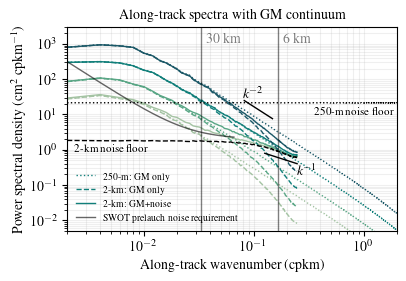

In [9]:
fig, ax = plt.subplots(figsize=(10 / 2.4, 7 / 2.4))

# Keep only positive frequencies for one-sided PSD visualization.
positive_wavenumber = l > 0

mag_plot_order = np.sort(np.asarray(mag_values))
mag_norm = colors.LogNorm(vmin=mag_plot_order.min()*0.2, vmax=mag_plot_order.max()*5)
mag_cmap = cmo.cm.tempo
mag_colors = mag_cmap(mag_norm(mag_plot_order))

for mag, line_color in zip(mag_plot_order, mag_colors):
    spec_250m_gm = unfiltered_spectra_by_mag[mag]['GM']
    ax.loglog(l[positive_wavenumber], spec_250m_gm[positive_wavenumber], ':', color=line_color)

    spec_2km_total = filtered_spectra2km_by_mag[mag]['total']
    ax.loglog(l_2km[l_2km>0], spec_2km_total[l_2km>0], '-', color=line_color)

    spec_2km_gm = filtered_spectra2km_by_mag[mag]['GM']
    ax.loglog(l_2km[l_2km>0], spec_2km_gm[l_2km>0], '--', color=line_color)

spec = unfiltered_spectra_by_mag[mag_values[-1]]['noise']
ax.loglog(l[positive_wavenumber], spec[positive_wavenumber], linestyle=':', color='k')

spec = filtered_spectra2km_by_mag[mag_values[-1]]['noise']
ax.loglog(l_2km[l_2km>0], spec[l_2km>0], linestyle='--', color='k')

# Reference slopes for visual comparison
l_pos = l[(l > 8e-2) & (l < 0.15)]
ax.loglog(l_pos, l_pos**(-2) / 6, '-', color='k')
ax.text(8e-2, 30, r'$k^{-2}$', color='k')
l_pos = l[(l > 1/8) & (l < 1/4)]
ax.loglog(l_pos, l_pos**(-1) / 10, '-', color='k')
ax.text(0.25, 0.2, r'$k^{-1}$', color='k')
# SWOT prelaunch noise requirement curve
l_pos = l[(l > 0) & (l < 1/15)]
ax.loglog(l_pos, 2 + 0.00125 * l_pos**(-2), '-', color='k', alpha=0.6)

# Annotate the 6 km and 30 km wavenumbers
ymax = 3e3
ax.axvline(1 / 30, color='black', alpha=0.5)
ax.axvline(1 / 6, color='black', alpha=0.5)
ax.text(1 / 30 * 1.1, ymax * 0.7, '30 km', verticalalignment='top', alpha=0.5)
ax.text(1 / 6 * 1.1, ymax * 0.7, '6 km', verticalalignment='top', alpha=0.5)
ax.text(0.35, 10, r"250-m noise floor", fontsize=8)
ax.text(0.0023, 0.9, r"2-km noise floor", fontsize=8)

ax.set_xlabel("Along-track wavenumber (cpkm)")
ax.set_ylabel(r"Power spectral density (cm$^2$ cpkm$^{-1}$)")
ax.set_title('Along-track spectra with GM continuum')
ax.grid(True, which='both', alpha=0.2)

# Custom legend
style_handles = [
    plt.Line2D([0], [0], color=mag_colors[2], linestyle=':', label='250-m: GM only'),
    plt.Line2D([0], [0], color=mag_colors[2], linestyle='--', label='2-km: GM only'),
    plt.Line2D([0], [0], color=mag_colors[2], linestyle='-', label='2-km: GM+noise'),
    plt.Line2D([0], [0], color='k', linestyle='-', alpha=0.6, label='SWOT prelauch noise requirement'),
]
ax.legend(handles=style_handles, loc='lower left', frameon=False, fontsize=7)

ax.set_xlim([2e-3, 2])
ax.set_ylim([5e-3, ymax])

plt.tight_layout()
plt.savefig('figs/GM_whitered.pdf', bbox_inches='tight')
plt.show()